In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'Holt_Winters'

# Holt-Winters — 01: Otimização de Hiperparâmetros
**Grupo 1 | Séries Temporais**

Este notebook realiza a otimização dos hiperparâmetros do modelo **Exponential Smoothing (Holt-Winters)** para a série de preço de fechamento do Bitcoin.  

> **Importante:** O Holt-Winters é um modelo **univariado** — não utiliza variáveis externas. Serve como referência de baseline para os demais modelos.

**Regra do protocolo:** A seleção de hiperparâmetros ocorre **somente sobre o conjunto de treino** — o conjunto de teste jamais é utilizado nesta etapa.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import time
import itertools
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70
np.random.seed(RANDOM_STATE)

## 1. Carregamento dos Dados

In [3]:
df = pd.read_csv(DATA_DIR / 'bitcoin_limpo.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

n        = len(df)
n_train  = int(n * TRAIN_RATIO)
n_test   = n - n_train
data_corte = df.iloc[n_train]['date']

serie_completa = df.set_index('date')['priceClose']
serie_train    = serie_completa.iloc[:n_train]
serie_test     = serie_completa.iloc[n_train:]

print(f'Total: {n} obs  |  Treino: {n_train}  |  Teste: {n_test}')
print(f'Treino: {serie_train.index.min().date()} -> {serie_train.index.max().date()}')
print(f'Teste : {serie_test.index.min().date()}  -> {serie_test.index.max().date()}')
print(f'Corte : {data_corte.date()}')

Total: 2943 obs  |  Treino: 2060  |  Teste: 883
Treino: 2018-08-22 -> 2024-04-11
Teste : 2024-04-12  -> 2026-09-11
Corte : 2024-04-12


## 2. Espaço de Busca dos Hiperparâmetros

O Holt-Winters (Exponential Smoothing) possui os seguintes hiperparâmetros principais:

| Hiperparâmetro | Opções testadas | Efeito |
|----------------|----------------|--------|
| `trend` | `'add'`, `'mul'`, `None` | Componente de tendência: aditiva, multiplicativa ou sem tendência |
| `seasonal` | `'add'`, `'mul'`, `None` | Componente sazonal: aditiva, multiplicativa ou sem sazonalidade |
| `seasonal_periods` | `7`, `30` | Periodicidade sazonal (só se `seasonal` não for None) |
| `damped_trend` | `True`, `False` | Amortecimento da tendência para longas previsões |

Os parâmetros de suavização (`alpha` α, `beta` β, `gamma` γ) são otimizados **automaticamente** pelo statsmodels via MLE.

> **Nota:** `seasonal='mul'` requer que todos os valores da série sejam positivos — condição satisfeita para o Bitcoin.

In [4]:
# Espaço de busca
grid = []

# Sem componente sazonal
for trend in ['add', 'mul']:
    for damped in [False, True]:
        grid.append(dict(trend=trend, seasonal=None,
                         seasonal_periods=None, damped_trend=damped))

# Sem tendência e sem sazonalidade (simples)
grid.append(dict(trend=None, seasonal=None, seasonal_periods=None, damped_trend=False))

# Com componente sazonal
for trend in ['add', 'mul']:
    for seasonal in ['add', 'mul']:
        for periods in [7, 30]:
            for damped in [False, True]:
                # mul+mul com damped pode ser instável; incluir apenas combinações válidas
                grid.append(dict(trend=trend, seasonal=seasonal,
                                 seasonal_periods=periods, damped_trend=damped))

print(f'Total de configuracoes a testar: {len(grid)}')
for i, cfg in enumerate(grid[:5], 1):
    print(f'  {i}. {cfg}')
print('  ...')

Total de configuracoes a testar: 21
  1. {'trend': 'add', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False}
  2. {'trend': 'add', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': True}
  3. {'trend': 'mul', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False}
  4. {'trend': 'mul', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': True}
  5. {'trend': None, 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False}
  ...


## 3. Avaliação por Validação Cruzada Temporal (TimeSeriesSplit)

Usamos **TimeSeriesSplit** com 3 folds sobre o conjunto de treino para avaliar cada configuração sem tocar no conjunto de teste.

Para cada fold: ajustar o modelo no subconjunto de treino do fold → prever o subconjunto de validação → calcular MAE.

In [5]:
def avaliar_hw_cv(serie_train, config, n_splits=3):
    """
    Avalia uma configuração de Holt-Winters usando TimeSeriesSplit.
    Retorna o MAE médio nos folds de validação e o AIC do modelo treinado no full train.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=90)  # 90 dias de validação por fold
    maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(serie_train)):
        s_fold_train = serie_train.iloc[train_idx]
        s_fold_val   = serie_train.iloc[val_idx]

        # Mínimo necessário para seasonal_periods (ao menos 2 ciclos)
        min_obs = 60
        if config['seasonal_periods']:
            min_obs = max(min_obs, config['seasonal_periods'] * 2)
        if len(s_fold_train) < min_obs:
            continue

        try:
            model = ExponentialSmoothing(
                s_fold_train,
                trend=config['trend'],
                seasonal=config['seasonal'],
                seasonal_periods=config['seasonal_periods'],
                damped_trend=config['damped_trend']
            )
            fit = model.fit(optimized=True, remove_bias=True)
            preds = fit.forecast(len(s_fold_val))
            mae = mean_absolute_error(s_fold_val.values, preds.values)
            maes.append(mae)
        except Exception:
            return None, None

    if not maes:
        return None, None

    # AIC no treino completo
    try:
        model_full = ExponentialSmoothing(
            serie_train,
            trend=config['trend'],
            seasonal=config['seasonal'],
            seasonal_periods=config['seasonal_periods'],
            damped_trend=config['damped_trend']
        )
        fit_full = model_full.fit(optimized=True, remove_bias=True)
        aic = fit_full.aic
    except Exception:
        aic = np.nan

    return float(np.mean(maes)), aic

In [6]:
print('Iniciando grid search com TimeSeriesSplit (3 folds, 90 dias de val por fold)...')
print('-' * 80)

t0 = time.time()
resultados = []

for i, cfg in enumerate(grid):
    mae_cv, aic = avaliar_hw_cv(serie_train, cfg, n_splits=3)
    label = (
        f"trend={str(cfg['trend']):3s}  "
        f"seasonal={str(cfg['seasonal']):4s}  "
        f"periods={str(cfg['seasonal_periods']):4s}  "
        f"damped={str(cfg['damped_trend']):5s}"
    )

    if mae_cv is not None:
        resultados.append({
            'config': cfg,
            'mae_cv': mae_cv,
            'aic': aic,
            'label': label
        })
        print(f'[{i+1:2d}/{len(grid)}] {label}  ->  MAE_CV={mae_cv:,.2f}  AIC={aic:.1f}')
    else:
        print(f'[{i+1:2d}/{len(grid)}] {label}  ->  FALHOU')

elapsed = time.time() - t0
print(f'\nGrid search concluido em {elapsed:.1f}s  |  {len(resultados)} configuracoes validas')

Iniciando grid search com TimeSeriesSplit (3 folds, 90 dias de val por fold)...
--------------------------------------------------------------------------------


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: Value

[ 1/21] trend=add  seasonal=None  periods=None  damped=False  ->  MAE_CV=9,794.82  AIC=28695.3


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: Co

[ 2/21] trend=add  seasonal=None  periods=None  damped=True   ->  MAE_CV=9,544.58  AIC=28696.4


...

C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: Co

[20/21] trend=mul  seasonal=mul   periods=30    damped=False  ->  MAE_CV=9,910.50  AIC=28882.4


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: Co

[21/21] trend=mul  seasonal=mul   periods=30    damped=True   ->  MAE_CV=9,544.82  AIC=28881.5

Grid search concluido em 44.9s  |  21 configuracoes validas


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 4. Seleção da Melhor Configuração

In [7]:
# Ordenar por MAE_CV (critério primário de seleção)
df_res = pd.DataFrame(resultados).sort_values('mae_cv').reset_index(drop=True)

print('=== Top 10 Configuracoes (por MAE CV) ===')
print(df_res[['label','mae_cv','aic']].head(10).to_string(index=True))

melhor = df_res.iloc[0]
best_config = melhor['config']

print(f'\n>>> Melhor configuracao:')
print(f'    trend           = {best_config["trend"]}')
print(f'    seasonal        = {best_config["seasonal"]}')
print(f'    seasonal_periods= {best_config["seasonal_periods"]}')
print(f'    damped_trend    = {best_config["damped_trend"]}')
print(f'    MAE_CV          = {melhor["mae_cv"]:,.2f}')
print(f'    AIC             = {melhor["aic"]:.2f}')

=== Top 10 Configuracoes (por MAE CV) ===
                                                   label       mae_cv           aic
0   trend=mul  seasonal=None  periods=None  damped=False  8899.723484  28719.209933
1   trend=add  seasonal=mul   periods=7     damped=False  9022.523962  28707.386360
2   trend=add  seasonal=add   periods=7     damped=False  9062.495497  28709.772858
3   trend=mul  seasonal=add   periods=7     damped=False  9302.477122  28744.821035
4   trend=add  seasonal=mul   periods=7     damped=True   9421.665239  28710.777515
5   trend=mul  seasonal=mul   periods=7     damped=False  9477.427690  28743.112030
6   trend=mul  seasonal=mul   periods=7     damped=True   9504.705304  28736.396622
7  trend=None  seasonal=None  periods=None  damped=False  9540.414166  28690.215412
8   trend=add  seasonal=add   periods=30    damped=True   9541.347912  28765.699016
9   trend=mul  seasonal=None  periods=None  damped=True   9543.068765  28696.353279

>>> Melhor configuracao:
    tren

## 5. Treinamento Final no Conjunto de Treino Completo

In [8]:
model_final = ExponentialSmoothing(
    serie_train,
    trend=best_config['trend'],
    seasonal=best_config['seasonal'],
    seasonal_periods=best_config['seasonal_periods'],
    damped_trend=best_config['damped_trend']
)
fit_final = model_final.fit(optimized=True, remove_bias=True)

# Parâmetros de suavização otimizados
print('=== Parametros de Suavizacao Otimizados (MLE) ===')
params = fit_final.params
print(f'  alpha (nivel)     = {params.get("smoothing_level", float("nan")):.6f}')
print(f'  beta  (tendencia) = {params.get("smoothing_trend", float("nan")):.6f}')
print(f'  gamma (sazonal)   = {params.get("smoothing_seasonal", float("nan")):.6f}')
print(f'  phi   (dampening) = {params.get("damping_trend", float("nan")):.6f}')
print()
print(f'  AIC   = {fit_final.aic:.4f}')
print(f'  BIC   = {fit_final.bic:.4f}')
print(f'  SSE   = {fit_final.sse:.4f}')

=== Parametros de Suavizacao Otimizados (MLE) ===
  alpha (nivel)     = 0.924286
  beta  (tendencia) = 0.022544
  gamma (sazonal)   = nan
  phi   (dampening) = nan

  AIC   = 28719.2099
  BIC   = 28741.7318
  SSE   = 2327223613.2067


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 6. Comparação Visual: Configurações por MAE

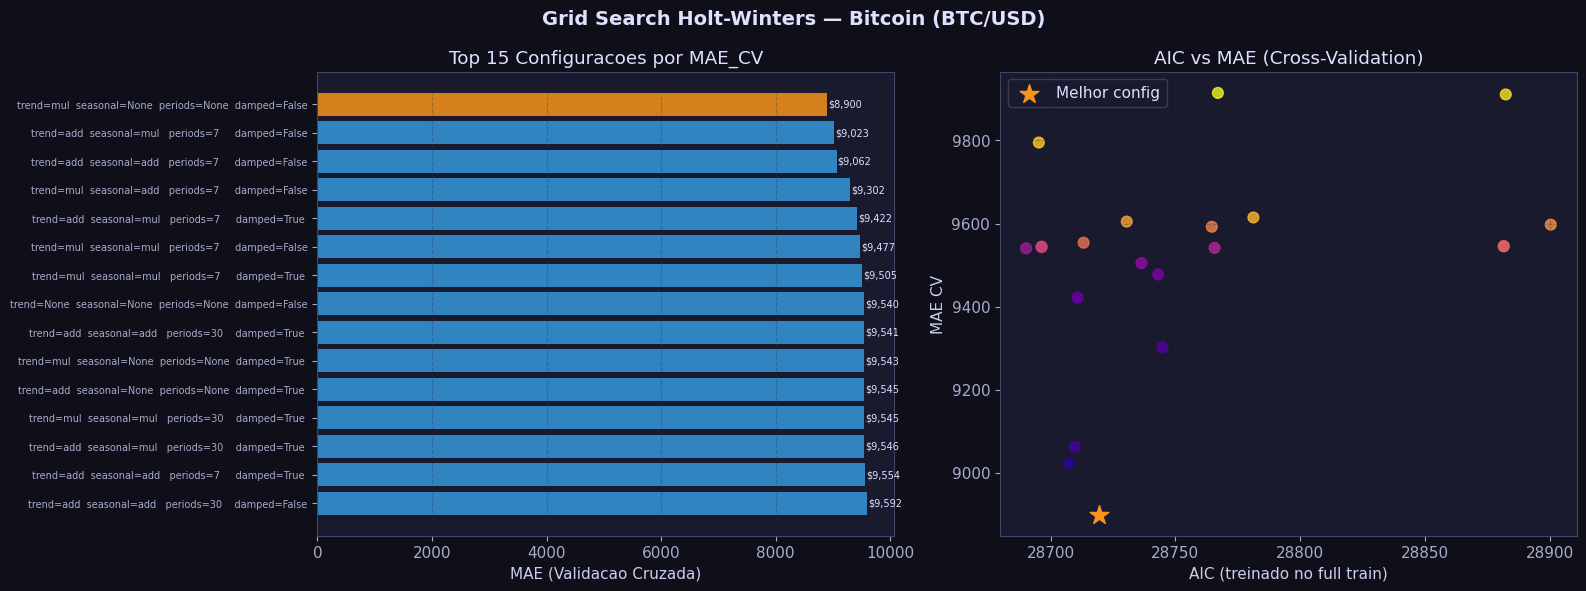

In [9]:
top_n = min(15, len(df_res))
df_top = df_res.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f0f1a')
fig.suptitle('Grid Search Holt-Winters — Bitcoin (BTC/USD)',
             color='#e0e0ff', fontsize=14, fontweight='bold')

# MAE por configuração
cores = ['#f7931a' if i == 0 else '#3498db' for i in range(top_n)]
bars = axes[0].barh(range(top_n), df_top['mae_cv'].values, color=cores, alpha=0.85)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f"{r['label']}" for _, r in df_top.iterrows()], fontsize=7)
axes[0].set_xlabel('MAE (Validacao Cruzada)')
axes[0].set_title(f'Top {top_n} Configuracoes por MAE_CV', color='#e0e0ff')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()
for bar, val in zip(bars, df_top['mae_cv'].values):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=7, color='#e0e0ff')

# AIC vs MAE scatter
scatter = axes[1].scatter(
    df_res['aic'].values, df_res['mae_cv'].values,
    c=range(len(df_res)), cmap='plasma', s=60, alpha=0.8
)
# Destacar melhor
axes[1].scatter(
    [melhor['aic']], [melhor['mae_cv']],
    color='#f7931a', s=200, marker='*', zorder=5, label='Melhor config'
)
axes[1].set_xlabel('AIC (treinado no full train)')
axes[1].set_ylabel('MAE CV')
axes[1].set_title('AIC vs MAE (Cross-Validation)', color='#e0e0ff')
axes[1].legend(framealpha=0.2)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_01_gridsearch.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 7. Análise de Sensibilidade dos Parâmetros de Suavização

C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: Value

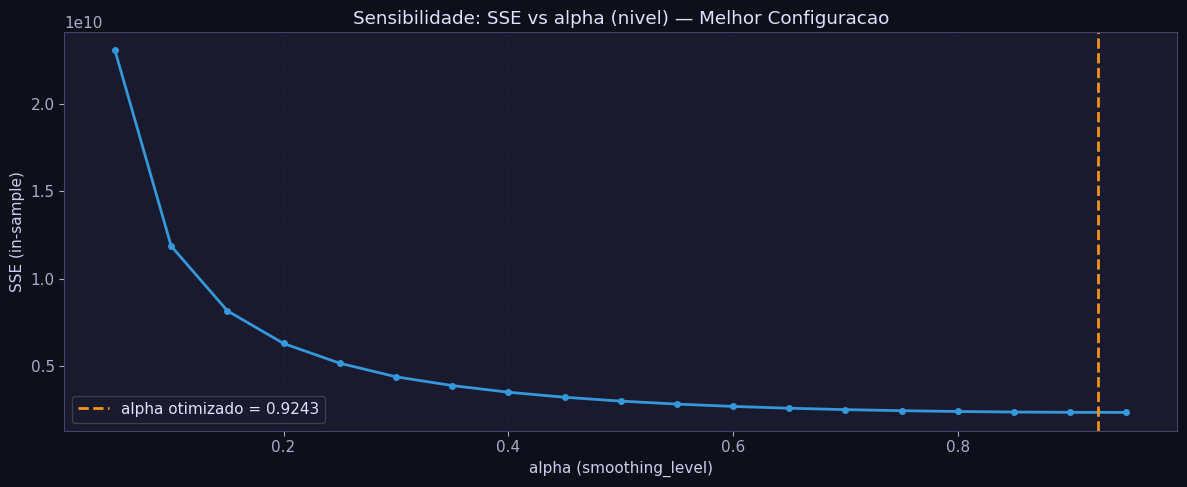

Alpha otimizado automaticamente: 0.9243


In [10]:
# Verificar sensibilidade do alpha (nível) no modelo com a melhor estrutura
alphas = np.linspace(0.05, 0.95, 19)
maes_alpha = []

for a in alphas:
    try:
        m = ExponentialSmoothing(
            serie_train,
            trend=best_config['trend'],
            seasonal=best_config['seasonal'],
            seasonal_periods=best_config['seasonal_periods'],
            damped_trend=best_config['damped_trend']
        )
        # Fixar alpha e otimizar o resto
        f = m.fit(smoothing_level=a, optimized=True, remove_bias=True)
        pred = f.forecast(90)
        # Usar in-sample residuos como proxy
        maes_alpha.append((a, f.sse))
    except:
        maes_alpha.append((a, np.nan))

df_alpha = pd.DataFrame(maes_alpha, columns=['alpha', 'sse'])

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f0f1a')
ax.plot(df_alpha['alpha'], df_alpha['sse'], color='#3498db', linewidth=2, marker='o', markersize=4)
alpha_otimizado = fit_final.params.get('smoothing_level', np.nan)
ax.axvline(alpha_otimizado, color='#f7931a', linestyle='--', linewidth=2,
           label=f'alpha otimizado = {alpha_otimizado:.4f}')
ax.set_title('Sensibilidade: SSE vs alpha (nivel) — Melhor Configuracao', color='#e0e0ff')
ax.set_xlabel('alpha (smoothing_level)')
ax.set_ylabel('SSE (in-sample)')
ax.legend(framealpha=0.2)
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_02_sensibilidade_alpha.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f'Alpha otimizado automaticamente: {alpha_otimizado:.4f}')

## 8. Exportação da Configuração Final

In [11]:
params_otimizados = fit_final.params

config_final = {
    'modelo': 'Holt-Winters (ExponentialSmoothing)',
    'base': 'bitcoin',
    'alvo': 'priceClose',
    'n_train': int(n_train),
    'n_test': int(n_test),
    'data_corte': str(data_corte.date()),
    'random_state': int(RANDOM_STATE),
    'train_ratio': float(TRAIN_RATIO),
    # Estrutura do modelo
    'trend': best_config['trend'],
    'seasonal': best_config['seasonal'],
    'seasonal_periods': best_config['seasonal_periods'],
    'damped_trend': best_config['damped_trend'],
    # Parâmetros de suavização (otimizados por MLE)
    'smoothing_level':    float(params_otimizados.get('smoothing_level', np.nan)),
    'smoothing_trend':    float(params_otimizados.get('smoothing_trend', np.nan)),
    'smoothing_seasonal': float(params_otimizados.get('smoothing_seasonal', np.nan)),
    'damping_trend':      float(params_otimizados.get('damping_trend', np.nan)),
    # Métricas de seleção
    'mae_cv': float(melhor['mae_cv']),
    'aic': float(melhor['aic']),
    'bic': float(fit_final.bic),
    'sse': float(fit_final.sse),
    # Resultados do grid search
    'n_configs_testadas': len(grid),
    'n_configs_validas': len(resultados),
    'metodo_selecao': 'TimeSeriesSplit (3 folds, 90 dias por fold), criterio MAE_CV'
}

with open(OUTPUT_DIR / 'hw_config_final.json', 'w', encoding='utf-8') as f:
    json.dump(config_final, f, indent=2, ensure_ascii=False)

# Exportar também os resultados do grid search
df_res_export = df_res.copy()
df_res_export['trend']            = df_res_export['config'].apply(lambda x: x['trend'])
df_res_export['seasonal']         = df_res_export['config'].apply(lambda x: x['seasonal'])
df_res_export['seasonal_periods'] = df_res_export['config'].apply(lambda x: x['seasonal_periods'])
df_res_export['damped_trend']     = df_res_export['config'].apply(lambda x: x['damped_trend'])
df_res_export.drop(columns=['config'], inplace=True)
df_res_export.to_csv(OUTPUT_DIR / 'hw_gridsearch_resultados.csv', index=False)

print('Arquivos exportados:')
print('  hw_config_final.json        — configuracao selecionada e parametros')
print('  hw_gridsearch_resultados.csv — todos os resultados do grid search')
print()
print('=== Resumo da Configuracao Final ===')
for k, v in config_final.items():
    if k != 'metodo_selecao':
        print(f'  {k}: {v}')

Arquivos exportados:
  hw_config_final.json        — configuracao selecionada e parametros
  hw_gridsearch_resultados.csv — todos os resultados do grid search

=== Resumo da Configuracao Final ===
  modelo: Holt-Winters (ExponentialSmoothing)
  base: bitcoin
  alvo: priceClose
  n_train: 2060
  n_test: 883
  data_corte: 2024-04-12
  random_state: 42
  train_ratio: 0.7
  trend: mul
  seasonal: None
  seasonal_periods: None
  damped_trend: False
  smoothing_level: 0.9242857142857143
  smoothing_trend: 0.02254355400696864
  smoothing_seasonal: nan
  damping_trend: nan
  mae_cv: 8899.7234837149
  aic: 28719.20993284958
  bic: 28741.73177789671
  sse: 2327223613.206657
  n_configs_testadas: 21
  n_configs_validas: 21


## 9. Justificativa das Escolhas

| Decisão | Justificativa |
|---------|---------------|
| **Critério primário: MAE_CV** | MAE é a métrica comparativa do trabalho; CV temporal evita leakage |
| **TimeSeriesSplit (3 folds)** | Respeita a ordem temporal; fold de validação = 90 dias (horizonte relevante) |
| **AIC como critério secundário** | Penaliza complexidade; útil para desempate entre configs de MAE similar |
| **`optimized=True`** | Parâmetros α, β, γ estimados por MLE — mais robusto que grid manual |
| **`remove_bias=True`** | Remove viés da inicialização para séries com nível elevado |
| **Modelo univariado** | HW não suporta variáveis externas por design — tratado como baseline |

**Próximo passo:** `02_walkforward_validacao.ipynb`